In [1]:
from timm.task import distillation
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib transformers

/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import ClusteringPipeline
import Student
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

my_root_path = "/mnt/windows/Users/kevin/Downloads/"
def get_input(idx):
        """
        Returns x for a given idx.
        """
        img = Image.open(Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png').convert('RGB')
        return img

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


2026-04-26 10:39:38,112 - INFO - HTTP Request: HEAD https://huggingface.co/samarkhanna/ExPLoRA/resolve/main/explora_dinov2_fmow_rgb/explora_dinov2_vit_base_fmow_rgb_encoder_only.pth "HTTP/1.1 302 Found"
2026-04-26 10:39:38,113 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Using cache found in /home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)

--- Sampling 500 images per class ---
Extracting features...


Extracting: 100%|██████████| 20/20 [10:14<00:00, 30.71s/it]


Saving new embeddings dataset to disk...
--- Reducing dimensionality using TSNE ---


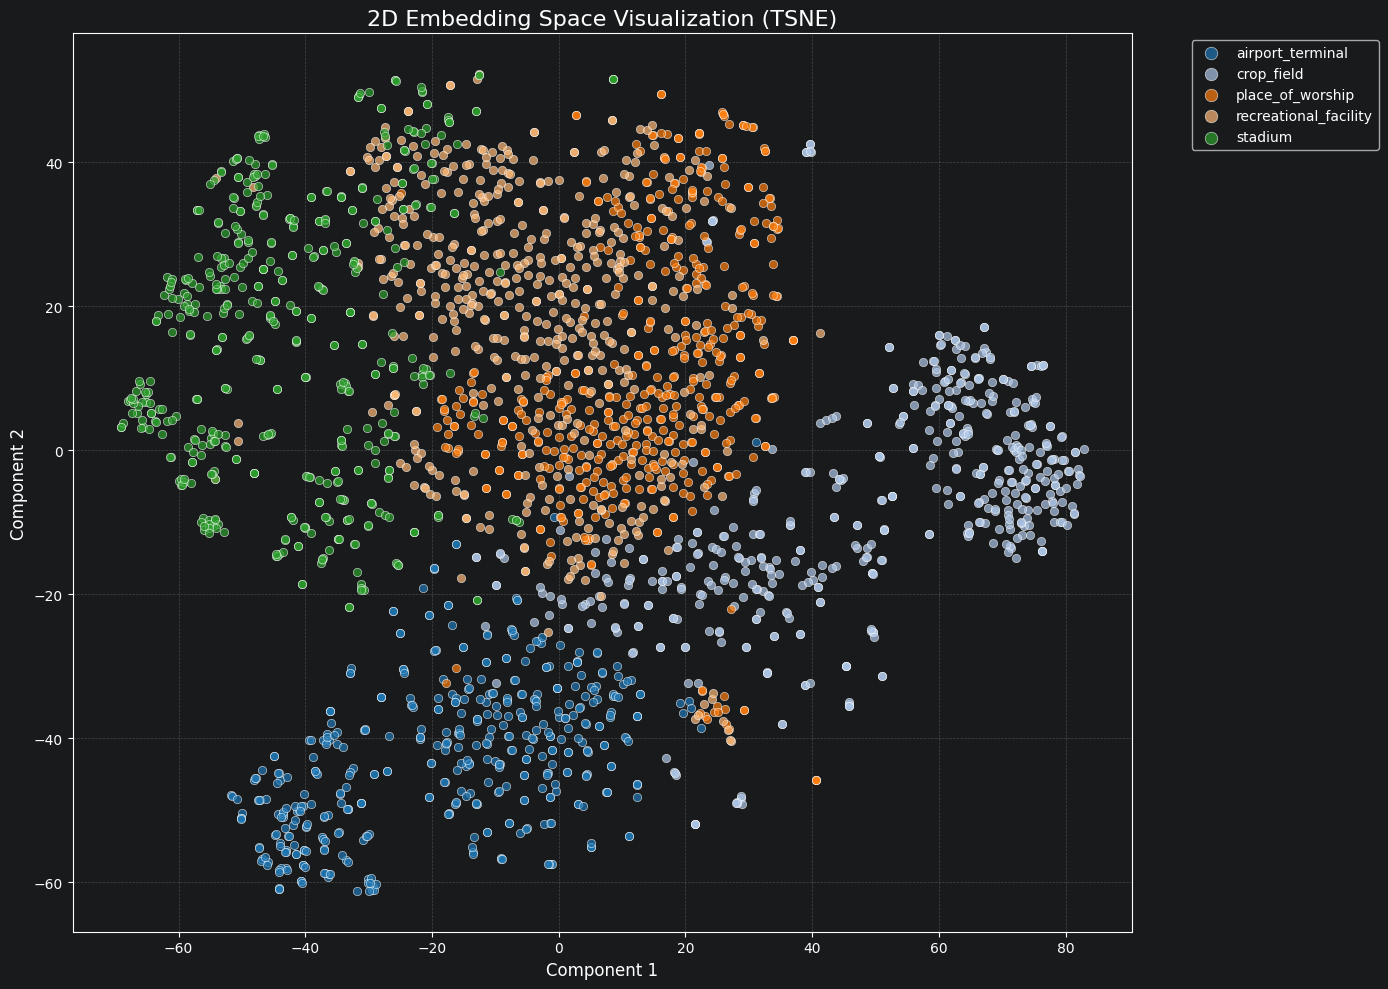

In [3]:
import FoundationModel
pipeline = ClusteringPipeline.ClusteringPipeline()
df_full = pipeline.get_dataset()
FM = FoundationModel.FoundationModel()

df_sample = pipeline.sample_dataset(df_full, samples_per_class=500)


df_base = pipeline.get_embeddings(df_sample, FM, get_input, preprocess,save_path="./dino")

pipeline.visualize_embedding_space(df_base,color_by='category')

embedding_dim_base = len(df_base['embedding'].iloc[0])

Clustering embeddings...
Distribution of images across the new macro-classes:
macro_class
1    1949
2     500
Name: count, dtype: int64


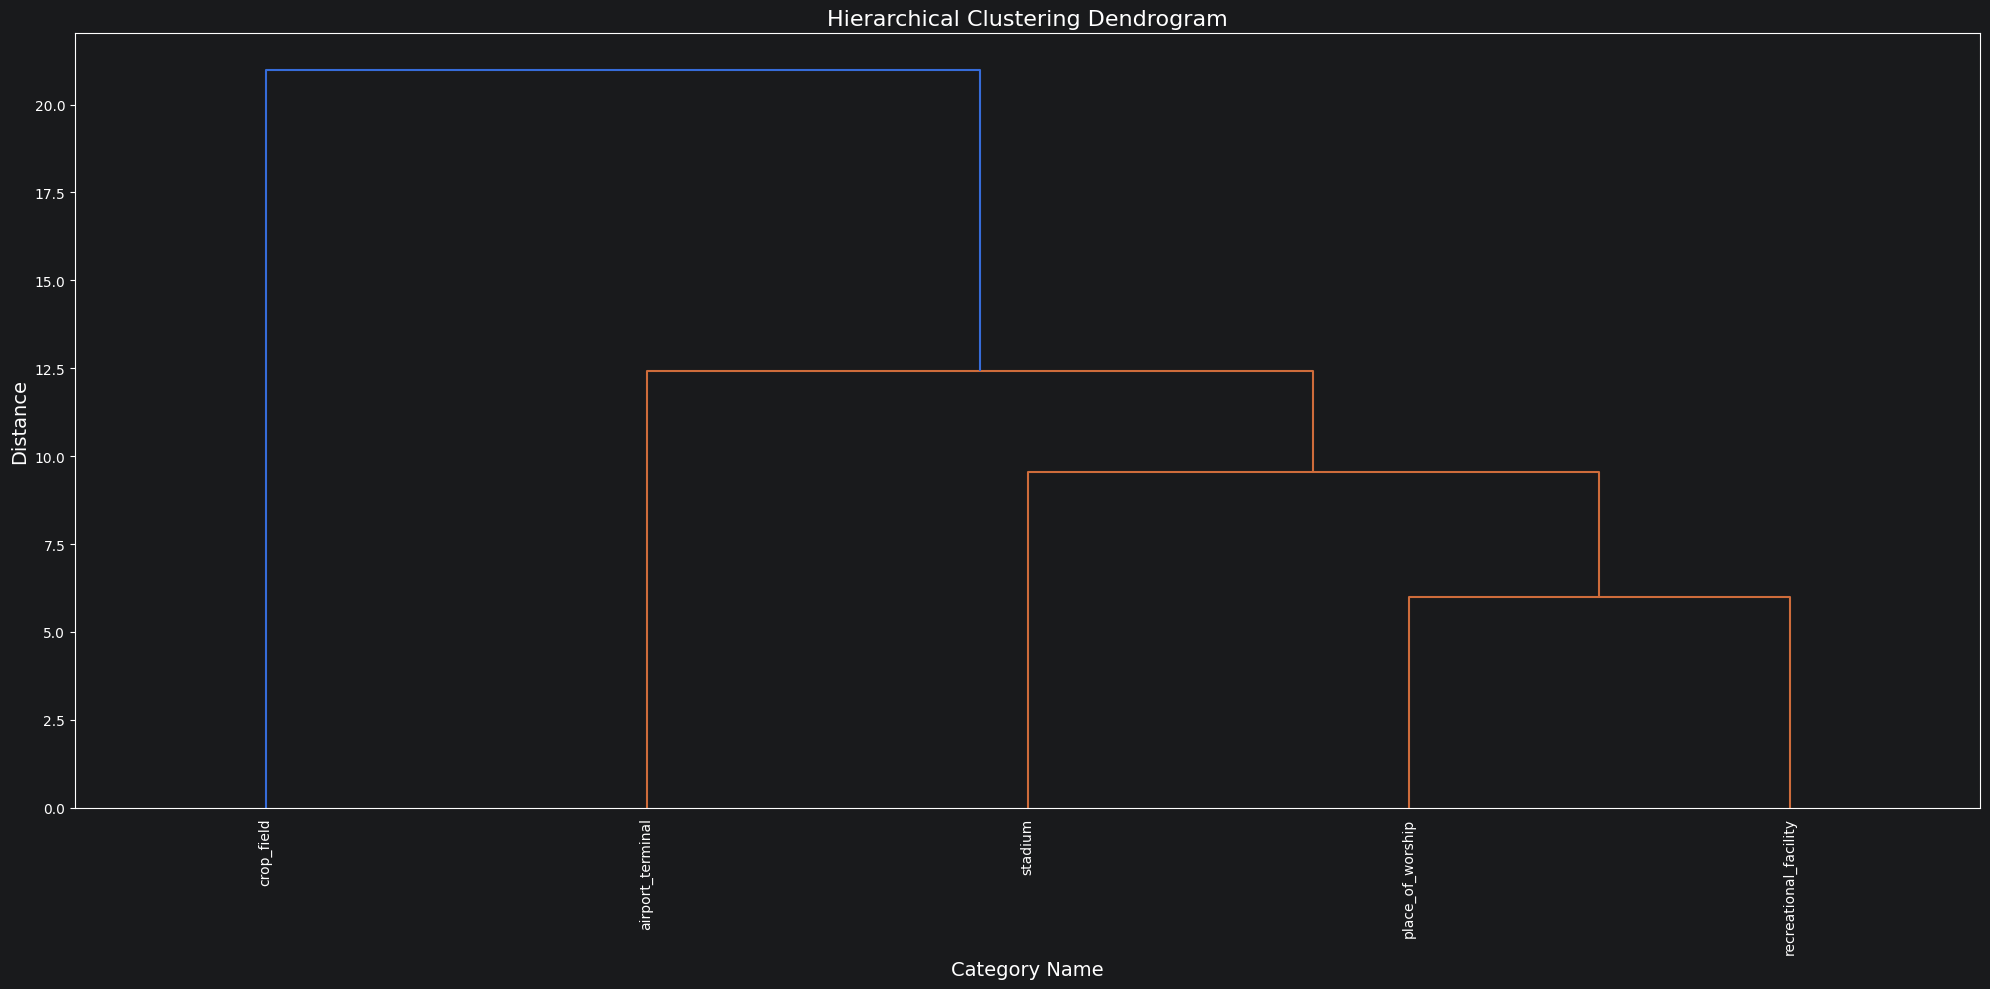

,original_index,category,embedding,macro_class
0,111685,airport_terminal,"[0.13185303, -0.2456619, -0.46839127, -0.45784...",1
1,111840,airport_terminal,"[0.029637571, -0.3332947, -0.31782183, -0.0442...",1
2,109189,airport_terminal,"[0.33701473, -0.57661176, -0.55244017, 0.12792...",1
3,407987,airport_terminal,"[0.081805095, 0.522436, -0.21260408, 0.0255424...",1
4,108589,airport_terminal,"[-0.16800044, -0.05691245, -0.37547752, -1.208...",1
...,...,...,...,...
2444,420651,stadium,"[-0.4251979, 0.58875734, -0.07297432, -0.78283...",1
2445,508753,stadium,"[0.31886137, -0.8619588, -0.14065523, -1.17655...",1
2446,263158,stadium,"[0.5334938, -0.8178152, 0.017133284, 0.4392664...",1
2447,420379,stadium,"[0.09231573, -0.1121326, -0.0641978, -0.691048...",1


In [4]:
pipeline.cluster_by_class(df = df_base,num_clusters=2)

In [29]:
from torch import nn
import FeatureDistillation

student = Student.Student(numberOfClasses=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(student.parameters()),lr=1e-3)
pipeline.train_online(
    df = df_base,
    model=student,
    criterion=criterion,
    optimizer=optimizer,
    get_input_fn=get_input, # Your image loading function
    transform_fn=preprocess,     # Your torchvision transforms
    target_col='category',
    batch_size=50,
    num_epochs_per_batch=2,
    order_by_concept=False,
    shuffle = False,
)

--- Avvio Streaming Pipeline (Prequential Evaluation) ---


Stream:   2%|▏         | 56/2449 [00:08<14:59,  2.66it/s]

Loss output student: 1.7424
Sample visti: 50 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream:   4%|▍         | 104/2449 [00:15<13:13,  2.96it/s]

Loss output student: 0.5415
Sample visti: 100 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


...

Loss output student: 0.5653
Sample visti: 2350 | Classi corrette: 744 | Accuratezza Cumulata: 31.66%


Stream:  98%|█████████▊| 2406/2449 [05:27<00:13,  3.28it/s]

Loss output student: 0.2343
Sample visti: 2400 | Classi corrette: 794 | Accuratezza Cumulata: 33.08%


Stream: 100%|██████████| 2449/2449 [05:29<00:00,  7.44it/s]



--- Fine Stream | Accuratezza Finale: 34.42% ---


In [30]:
from torch import nn
import FeatureDistillation

student = Student.Student(numberOfClasses=5)
distillator = FeatureDistillation.MLPDistiller(dimFeatureStudent=512,dimFeatureTeacher=embedding_dim_base,hiddenLayerSize=300)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(student.parameters()) + list(distillator.parameters()),lr=1e-3)
pipeline.train_online(
    df = df_base,
    model=student,
    criterion=criterion,
    optimizer=optimizer,
    get_input_fn=get_input, # Your image loading function
    transform_fn=preprocess,     # Your torchvision transforms
    target_col='category',
    batch_size=50,
    num_epochs_per_batch=2,
    order_by_concept=False,
    shuffle = False,
    distillator = distillator
)

--- Avvio Streaming Pipeline (Prequential Evaluation) ---


Stream:   2%|▏         | 54/2449 [00:08<16:50,  2.37it/s]

Loss output student: 1.1947
Loss distillation: 0.6209
Sample visti: 50 | Classi corrette: 6 | Accuratezza Cumulata: 12.00%


Stream:   4%|▍         | 103/2449 [00:15<17:18,  2.26it/s]

Loss output student: 0.3770
Loss distillation: 0.4756
Sample visti: 100 | Classi corrette: 6 | Accuratezza Cumulata: 6.00%


...

Loss output student: 0.7115
Loss distillation: 0.5449
Sample visti: 2350 | Classi corrette: 771 | Accuratezza Cumulata: 32.81%


Stream:  98%|█████████▊| 2406/2449 [05:32<00:13,  3.21it/s]

Loss output student: 0.2229
Loss distillation: 0.6577
Sample visti: 2400 | Classi corrette: 771 | Accuratezza Cumulata: 32.12%


Stream: 100%|██████████| 2449/2449 [05:33<00:00,  7.34it/s]



--- Fine Stream | Accuratezza Finale: 33.48% ---


In [31]:
from torch import nn
import FeatureDistillation

student = Student.Student(numberOfClasses=5)
distillator = FeatureDistillation.LinearReluDistiller(dimFeatureStudent=512,dimFeatureTeacher=embedding_dim_base)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(student.parameters()) + list(distillator.parameters()),lr=1e-3)
pipeline.train_online(
    df = df_base,
    model=student,
    criterion=criterion,
    optimizer=optimizer,
    get_input_fn=get_input, # Your image loading function
    transform_fn=preprocess,     # Your torchvision transforms
    target_col='category',
    batch_size=50,
    num_epochs_per_batch=2,
    order_by_concept=False,
    shuffle = False,
    distillator = distillator
)

--- Avvio Streaming Pipeline (Prequential Evaluation) ---


Stream:   2%|▏         | 55/2449 [00:07<14:13,  2.81it/s]

Loss output student: 1.3301
Loss distillation: 0.8361
Sample visti: 50 | Classi corrette: 5 | Accuratezza Cumulata: 10.00%


Stream:   4%|▍         | 103/2449 [00:14<13:58,  2.80it/s]

Loss output student: 0.4106
Loss distillation: 0.5749
Sample visti: 100 | Classi corrette: 6 | Accuratezza Cumulata: 6.00%


...

Loss output student: 1.0476
Loss distillation: 0.4720
Sample visti: 2350 | Classi corrette: 721 | Accuratezza Cumulata: 30.68%


Stream:  98%|█████████▊| 2404/2449 [05:43<00:15,  2.90it/s]

Loss output student: 0.4983
Loss distillation: 0.5712
Sample visti: 2400 | Classi corrette: 743 | Accuratezza Cumulata: 30.96%


Stream: 100%|██████████| 2449/2449 [05:44<00:00,  7.11it/s]


--- Fine Stream | Accuratezza Finale: 32.34% ---


In [38]:
from torch import nn
import FeatureDistillation

student = Student.Student(numberOfClasses=5)
distillator = FeatureDistillation.LinearBNLogSumDistiller(dimFeatureStudent=512,dimFeatureTeacher=embedding_dim_base)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(student.parameters()) + list(distillator.parameters()),lr=1e-3)
pipeline.train_online(
    df = df_base,
    model=student,
    criterion=criterion,
    optimizer=optimizer,
    get_input_fn=get_input, # Your image loading function
    transform_fn=preprocess,     # Your torchvision transforms
    target_col='category',
    batch_size=50,
    num_epochs_per_batch=1,
    order_by_concept=False,
    shuffle = True,
    distillator = distillator
)

--- Avvio Streaming Pipeline (Prequential Evaluation) ---
Shuffling the dataset before streaming...


Stream:   2%|▏         | 54/2449 [00:06<12:20,  3.23it/s]

Loss output student: 1.7408
Loss distillation: 7.2693
Sample visti: 50 | Classi corrette: 11 | Accuratezza Cumulata: 22.00%


Stream:   4%|▍         | 105/2449 [00:10<07:57,  4.91it/s]

Loss output student: 0.8258
Loss distillation: 7.2524
Sample visti: 100 | Classi corrette: 28 | Accuratezza Cumulata: 28.00%


...

Loss output student: 0.5151
Loss distillation: 6.3616
Sample visti: 2350 | Classi corrette: 1523 | Accuratezza Cumulata: 64.81%


Stream:  98%|█████████▊| 2404/2449 [03:24<00:07,  5.93it/s]

Loss output student: 0.3030
Loss distillation: 6.3227
Sample visti: 2400 | Classi corrette: 1567 | Accuratezza Cumulata: 65.29%


Stream: 100%|██████████| 2449/2449 [03:25<00:00, 11.89it/s]


--- Fine Stream | Accuratezza Finale: 65.29% ---


In [35]:
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

classifier = LinearProbe(num_classes=5,input_dim=embedding_dim_base)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(classifier.parameters()),lr=1e-3)
pipeline.linear_probing_online(
    classifier=classifier,
    df= df_base,
    criterion=criterion,
    optimizer=optimizer,
    batch_size=50,
    num_epochs_per_batch=1,
    shuffle=False)



--- Avvio Streaming Pipeline (Linear Probing Online su Embeddings Pre-calcolati) ---


Stream:  11%|█         | 269/2449 [00:00<00:00, 2689.78it/s]

Sample visti: 50 | Classi corrette: 19 | Accuratezza Cumulata: 38.00%
Sample visti: 100 | Classi corrette: 46 | Accuratezza Cumulata: 46.00%
Sample visti: 150 | Classi corrette: 88 | Accuratezza Cumulata: 58.67%
Sample visti: 200 | Classi corrette: 127 | Accuratezza Cumulata: 63.50%
Sample visti: 250 | Classi corrette: 176 | Accuratezza Cumulata: 70.40%
Sample visti: 300 | Classi corrette: 225 | Accuratezza Cumulata: 75.00%
Sample visti: 350 | Classi corrette: 275 | Accuratezza Cumulata: 78.57%
Sample visti: 400 | Classi corrette: 325 | Accuratezza Cumulata: 81.25%
Sample visti: 450 | Classi corrette: 374 | Accuratezza Cumulata: 83.11%
Sample visti: 500 | Classi corrette: 390 | Accuratezza Cumulata: 78.00%


Stream:  22%|██▏       | 550/2449 [00:00<00:00, 2758.02it/s]

Sample visti: 550 | Classi corrette: 415 | Accuratezza Cumulata: 75.45%
Sample visti: 600 | Classi corrette: 447 | Accuratezza Cumulata: 74.50%


...

Sample visti: 1300 | Classi corrette: 774 | Accuratezza Cumulata: 59.54%
Sample visti: 1350 | Classi corrette: 806 | Accuratezza Cumulata: 59.70%
Sample visti: 1400 | Classi corrette: 841 | Accuratezza Cumulata: 60.07%
Sample visti: 1450 | Classi corrette: 873 | Accuratezza Cumulata: 60.21%
Sample visti: 1500 | Classi corrette: 873 | Accuratezza Cumulata: 58.20%
Sample visti: 1550 | Classi corrette: 873 | Accuratezza Cumulata: 56.32%
Sample visti: 1600 | Classi corrette: 873 | Accuratezza Cumulata: 54.56%
Sample visti: 1650 | Classi corrette: 873 | Accuratezza Cumulata: 52.91%
Sample visti: 1700 | Classi corrette: 877 | Accuratezza Cumulata: 51.59%
Sample visti: 1750 | Classi corrette: 878 | Accuratezza Cumulata: 50.17%
Sample visti: 1800 | Classi corrette: 884 | Accuratezza Cumulata: 49.11%
Sample visti: 1850 | Classi corrette: 892 | Accuratezza Cumulata: 48.22%


Stream:  97%|█████████▋| 2372/2449 [00:00<00:00, 2934.76it/s]

Sample visti: 1900 | Classi corrette: 905 | Accuratezza Cumulata: 47.63%
Sample visti: 1950 | Classi corrette: 920 | Accuratezza Cumulata: 47.18%
Sample visti: 2000 | Classi corrette: 924 | Accuratezza Cumulata: 46.20%
Sample visti: 2050 | Classi corrette: 926 | Accuratezza Cumulata: 45.17%
Sample visti: 2100 | Classi corrette: 929 | Accuratezza Cumulata: 44.24%
Sample visti: 2150 | Classi corrette: 937 | Accuratezza Cumulata: 43.58%
Sample visti: 2200 | Classi corrette: 948 | Accuratezza Cumulata: 43.09%
Sample visti: 2250 | Classi corrette: 968 | Accuratezza Cumulata: 43.02%
Sample visti: 2300 | Classi corrette: 989 | Accuratezza Cumulata: 43.00%
Sample visti: 2350 | Classi corrette: 1022 | Accuratezza Cumulata: 43.49%
Sample visti: 2400 | Classi corrette: 1056 | Accuratezza Cumulata: 44.00%


Stream: 100%|██████████| 2449/2449 [00:00<00:00, 2910.38it/s]


--- Fine Stream | Accuratezza Finale Linear Probing: 44.14% ---
